In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("goodreads_data.csv")
df.head()

,Unnamed: 0,Book,Author,Description,Genres,Avg_Rating,Num_Ratings,URL
0,0,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"['Classics', 'Fiction', 'Historical Fiction', ...",4.27,"5,691,311",https://www.goodreads.com/book/show/2657.To_Ki...
1,1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,Harry Potter thinks he is an ordinary boy - un...,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4.47,"9,278,135",https://www.goodreads.com/book/show/72193.Harr...
2,2,Pride and Prejudice,Jane Austen,"Since its immediate success in 1813, Pride and...","['Classics', 'Fiction', 'Romance', 'Historical...",4.28,"3,944,155",https://www.goodreads.com/book/show/1885.Pride...
3,3,The Diary of a Young Girl,Anne Frank,Discovered in the attic in which she spent the...,"['Classics', 'Nonfiction', 'History', 'Biograp...",4.18,"3,488,438",https://www.goodreads.com/book/show/48855.The_...
4,4,Animal Farm,George Orwell,Librarian's note: There is an Alternate Cover ...,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",3.98,"3,575,172",https://www.goodreads.com/book/show/170448.Ani...


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   10000 non-null  int64  
 1   Book         10000 non-null  object 
 2   Author       10000 non-null  object 
 3   Description  9923 non-null   object 
 4   Genres       10000 non-null  object 
 5   Avg_Rating   10000 non-null  float64
 6   Num_Ratings  10000 non-null  object 
 7   URL          10000 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


In [18]:
df = df.drop(columns=["Unnamed: 0", "URL"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Book         10000 non-null  object 
 1   Author       10000 non-null  object 
 2   Description  9923 non-null   object 
 3   Genres       10000 non-null  object 
 4   Avg_Rating   10000 non-null  float64
 5   Num_Ratings  10000 non-null  object 
dtypes: float64(1), object(5)
memory usage: 468.9+ KB


In [20]:
df = df.drop_duplicates(subset=["Book", "Author"])
df.shape

(9896, 6)

In [22]:
df = df.dropna(subset=["Description","Genres"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9820 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Book         9820 non-null   object 
 1   Author       9820 non-null   object 
 2   Description  9820 non-null   object 
 3   Genres       9820 non-null   object 
 4   Avg_Rating   9820 non-null   float64
 5   Num_Ratings  9820 non-null   object 
dtypes: float64(1), object(5)
memory usage: 537.0+ KB


In [24]:
df = df.drop_duplicates(subset=["Book", "Author"])
df.shape


(9820, 6)

In [26]:
df.to_csv("goodreads_cleaned.csv", index=False)


In [28]:
import pandas as pd
import numpy as np

df["text"] = (
    df["Book"].astype(str) + " " +
    df["Author"].astype(str) + " " +
    df["Genres"].astype(str) + " " +
    df["Description"].astype(str)
)

df[["Book", "Author", "Genres","Description"]].head()


,Book,Author,Genres,Description
0,To Kill a Mockingbird,Harper Lee,"['Classics', 'Fiction', 'Historical Fiction', ...",The unforgettable novel of a childhood in a sl...
1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",Harry Potter thinks he is an ordinary boy - un...
2,Pride and Prejudice,Jane Austen,"['Classics', 'Fiction', 'Romance', 'Historical...","Since its immediate success in 1813, Pride and..."
3,The Diary of a Young Girl,Anne Frank,"['Classics', 'Nonfiction', 'History', 'Biograp...",Discovered in the attic in which she spent the...
4,Animal Farm,George Orwell,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",Librarian's note: There is an Alternate Cover ...


In [30]:
df.columns

Index(['Book', 'Author', 'Description', 'Genres', 'Avg_Rating', 'Num_Ratings',
       'text'],
      dtype='object')

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=15000, ngram_range=(1,2), min_df=2)
tfidf_matrix = tfidf.fit_transform(df["text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (9820, 15000)


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

title_to_index = {}
for i, t in enumerate(df["Book"].tolist()):
    if t not in title_to_index:
        title_to_index[t] = i

def recommend_content_based(title, top_n=10):
    if title not in title_to_index:
        raise ValueError("Title not found in dataset.")
        
    idx = title_to_index[title]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    
    scores = [x for x in scores if x[0] != idx]
    top = scores[:top_n]
    
    rec_idx = [i for i, s in top]
    rec_scores = [s for i, s in top]
    
    out = df.iloc[rec_idx][["Book","Author","Genres","Avg_Rating","Num_Ratings"]].copy()
    out["Similarity"] = rec_scores
    return out.reset_index(drop=True)

recommend_content_based(df["Book"].iloc[0], top_n=10)



,Book,Author,Genres,Avg_Rating,Num_Ratings,Similarity
0,Harper Lee's To Kill a Mockingbird,Harold Bloom,"['Classics', 'Fiction', 'Historical Fiction', ...",4.43,"7,508",0.459556
1,Go Set a Watchman,Harper Lee,"['Fiction', 'Historical Fiction', 'Classics', ...",3.31,"262,779",0.442431
2,A Guide To To Kill A Mockingbird,Mary Hartley,[],4.24,143,0.181885
3,Mockingbird,Walter Tevis,"['Science Fiction', 'Fiction', 'Dystopia', 'Po...",4.16,"8,316",0.161091
4,"Raised by Hand, Lifted by the Tides: A Souther...",Willett Thomas,"['Historical Fiction', 'Fiction', 'Mystery', '...",3.83,42,0.136671
5,Their Eyes Were Watching God,Zora Neale Hurston,"['Classics', 'Fiction', 'Historical Fiction', ...",3.97,"324,281",0.111549
6,Amazing Grief A Healing Guide for Parents of Y...,Charles Harper,[],4.67,3,0.111508
7,"Pollyanna (Pollyanna, #1)",Eleanor H. Porter,"['Classics', 'Fiction', 'Childrens', 'Young Ad...",4.00,"84,420",0.111438
8,Joni: An Unforgettable Story,Joni Eareckson Tada,"['Biography', 'Nonfiction', 'Christian', 'Memo...",4.23,"31,121",0.109627
9,"Grave Sight (Harper Connelly, #1)",Charlaine Harris,"['Mystery', 'Paranormal', 'Fantasy', 'Urban Fa...",3.86,"63,624",0.107939


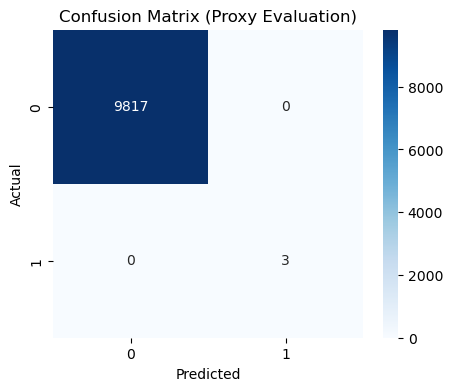

In [69]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

similarities = cosine_sim[0]

y_true = (similarities >= 0.3).astype(int)

y_pred = (similarities >= 0.3).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Proxy Evaluation)")
plt.show()


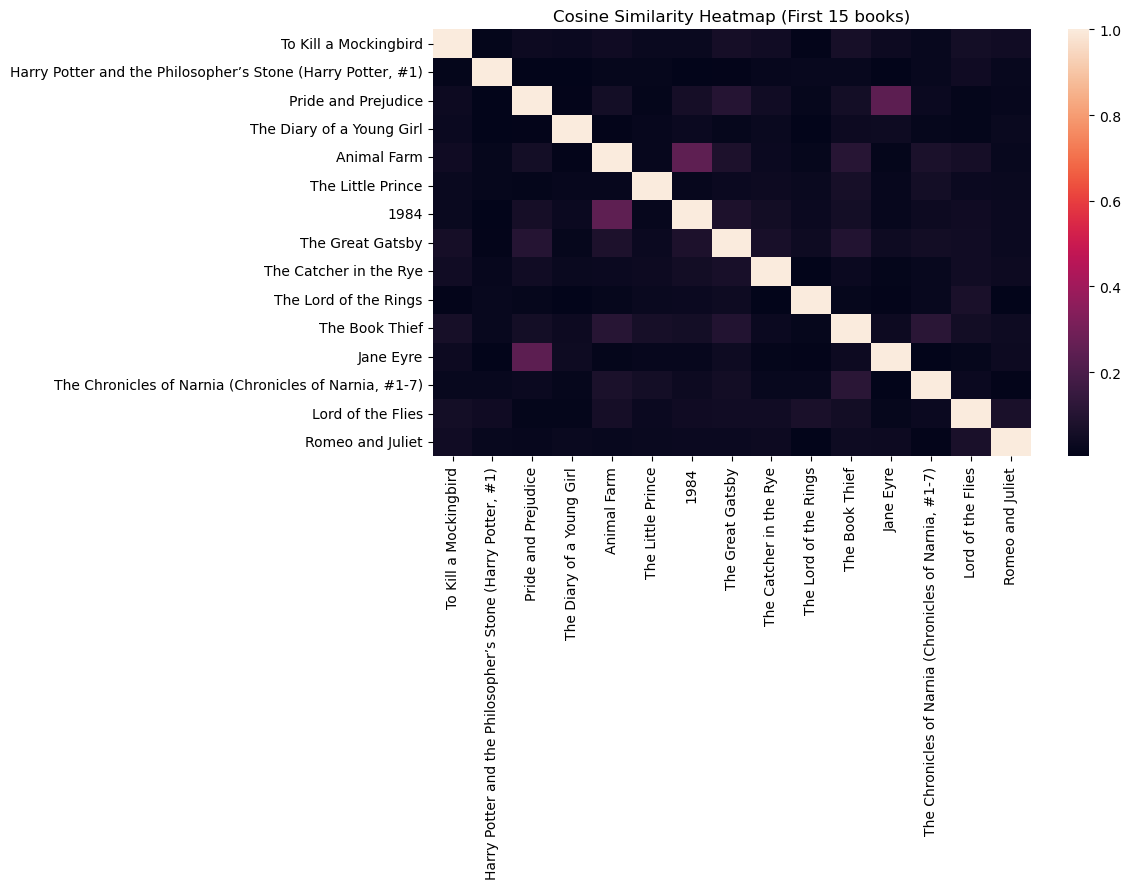

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
def plot_similarity_heatmap(cosine_sim, df, n=15):
    sim_block = cosine_sim[:n, :n]
    labels = df["Book"].iloc[:n].astype(str).tolist()

    plt.figure(figsize=(12, 9))
    sns.heatmap(sim_block, xticklabels=labels, yticklabels=labels)
    plt.title(f"Cosine Similarity Heatmap (First {n} books)")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_similarity_heatmap(cosine_sim, df, n=15)


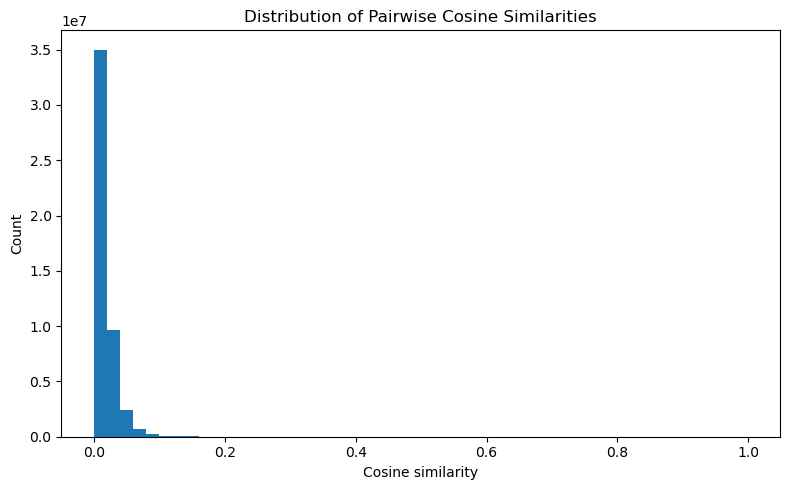

In [73]:
def plot_similarity_distribution(cosine_sim):
    vals = cosine_sim[np.triu_indices_from(cosine_sim, k=1)]
    plt.figure(figsize=(8,5))
    plt.hist(vals, bins=50)
    plt.xlabel("Cosine similarity")
    plt.ylabel("Count")
    plt.title("Distribution of Pairwise Cosine Similarities")
    plt.tight_layout()
    plt.show()

plot_similarity_distribution(cosine_sim)


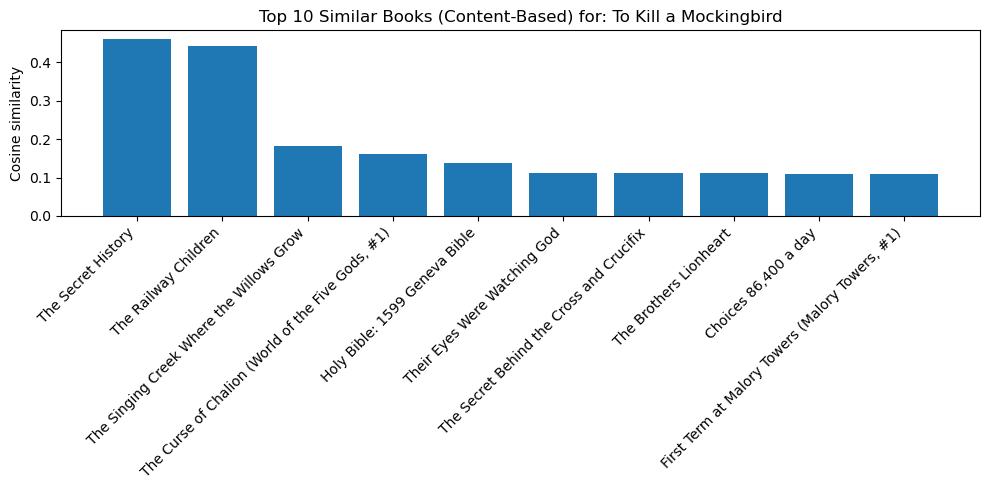

In [75]:
def plot_topn_similarity_bar(title, df, cosine_sim, title_to_index, top_n=10):
    if title not in title_to_index:
        print("Title not found.")
        return

    idx = title_to_index[title]
    sims = cosine_sim[idx].copy()
    sims[idx] = -1  # exclude itself

    top_idx = np.argsort(sims)[::-1][:top_n]
    top_titles = df.loc[top_idx, "Book"].astype(str).tolist()
    top_scores = sims[top_idx]

    plt.figure(figsize=(10,5))
    plt.bar(top_titles, top_scores)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Cosine similarity")
    plt.title(f"Top {top_n} Similar Books (Content-Based) for: {title}")
    plt.tight_layout()
    plt.show()

seed_title = df["Book"].iloc[0]
plot_topn_similarity_bar(seed_title, df, cosine_sim, title_to_index, top_n=10)


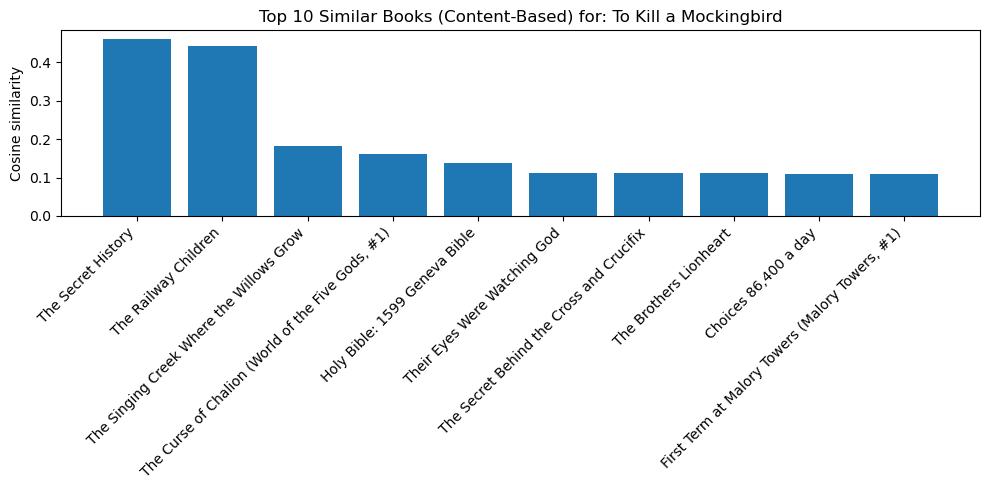

In [77]:
def plot_topn_similarity_bar(title, df, cosine_sim, title_to_index, top_n=10):
    if title not in title_to_index:
        print("Title not found.")
        return

    idx = title_to_index[title]
    sims = cosine_sim[idx].copy()
    sims[idx] = -1  # exclude itself

    top_idx = np.argsort(sims)[::-1][:top_n]
    top_titles = df.loc[top_idx, "Book"].astype(str).tolist()
    top_scores = sims[top_idx]

    plt.figure(figsize=(10,5))
    plt.bar(top_titles, top_scores)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Cosine similarity")
    plt.title(f"Top {top_n} Similar Books (Content-Based) for: {title}")
    plt.tight_layout()
    plt.show()

seed_title = df["Book"].iloc[0]
plot_topn_similarity_bar(seed_title, df, cosine_sim, title_to_index, top_n=10)


In [79]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=11,
    metric="cosine",
    algorithm="brute"
)

knn.fit(tfidf_matrix)

print("KNN model trained successfully")


KNN model trained successfully


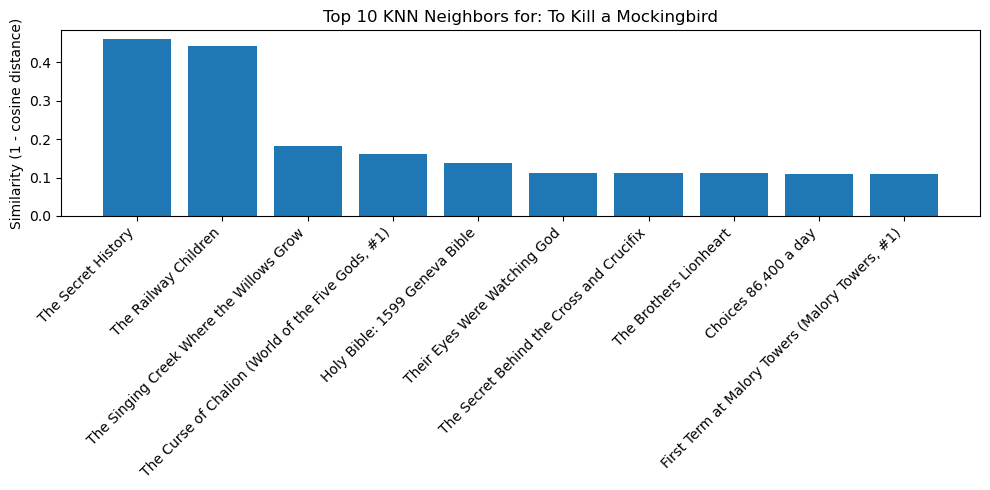

In [81]:
def plot_knn_neighbors(title, df, knn, tfidf_matrix, title_to_index, top_n=10):
    if title not in title_to_index:
        print("Title not found.")
        return

    idx = title_to_index[title]
    distances, indices = knn.kneighbors(tfidf_matrix[idx], n_neighbors=top_n+1)

    distances = distances.flatten()[1:]
    indices = indices.flatten()[1:]
    sims = 1 - distances

    labels = df.loc[indices, "Book"].astype(str).tolist()

    plt.figure(figsize=(10,5))
    plt.bar(labels, sims)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Similarity (1 - cosine distance)")
    plt.title(f"Top {top_n} KNN Neighbors for: {title}")
    plt.tight_layout()
    plt.show()

plot_knn_neighbors(seed_title, df, knn, tfidf_matrix, title_to_index, top_n=10)


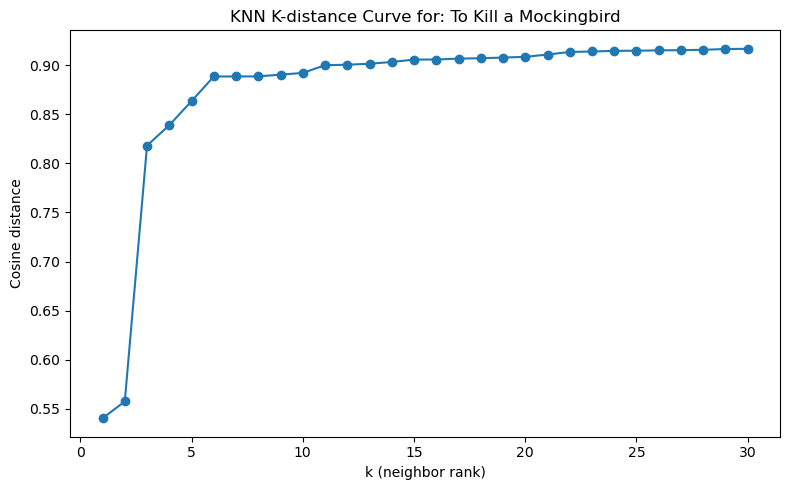

In [83]:
def plot_knn_kdistance_curve(title, df, knn, tfidf_matrix, title_to_index, k_max=30):
    if title not in title_to_index:
        print("Title not found.")
        return

    idx = title_to_index[title]
    distances, _ = knn.kneighbors(tfidf_matrix[idx], n_neighbors=k_max+1)
    d = distances.flatten()[1:]  # exclude itself

    plt.figure(figsize=(8,5))
    plt.plot(range(1, k_max+1), d, marker="o")
    plt.xlabel("k (neighbor rank)")
    plt.ylabel("Cosine distance")
    plt.title(f"KNN K-distance Curve for: {title}")
    plt.tight_layout()
    plt.show()

plot_knn_kdistance_curve(seed_title, df, knn, tfidf_matrix, title_to_index, k_max=30)


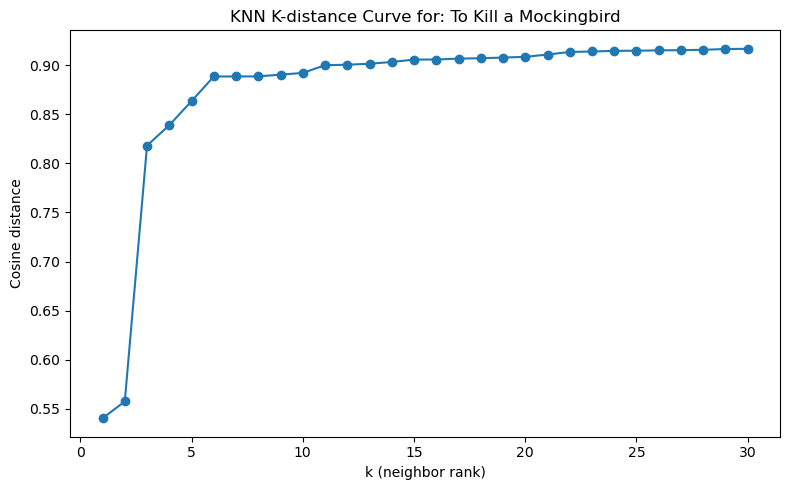

In [85]:
def plot_knn_kdistance_curve(title, df, knn, tfidf_matrix, title_to_index, k_max=30):
    if title not in title_to_index:
        print("Title not found.")
        return

    idx = title_to_index[title]
    distances, _ = knn.kneighbors(tfidf_matrix[idx], n_neighbors=k_max+1)
    d = distances.flatten()[1:]  # exclude itself

    plt.figure(figsize=(8,5))
    plt.plot(range(1, k_max+1), d, marker="o")
    plt.xlabel("k (neighbor rank)")
    plt.ylabel("Cosine distance")
    plt.title(f"KNN K-distance Curve for: {title}")
    plt.tight_layout()
    plt.show()

plot_knn_kdistance_curve(seed_title, df, knn, tfidf_matrix, title_to_index, k_max=30)


In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["text"] = df["Book"].astype(str) + " " + df["Author"].astype(str) + " " + df["Genres"].astype(str) + " " + df["Description"].astype(str)

tfidf = TfidfVectorizer(stop_words="english", max_features=15000, ngram_range=(1,2), min_df=2)
tfidf_matrix = tfidf.fit_transform(df["text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)



TF-IDF matrix shape: (9820, 15000)


In [88]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

svd = TruncatedSVD(n_components=120, random_state=42)
reduced = svd.fit_transform(tfidf_matrix)

k = 25
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
df["Cluster"] = kmeans.fit_predict(reduced)

print(" Cluster column created")
print("Number of clusters:", df["Cluster"].nunique())
df[["Book", "Author", "Cluster"]].head()


 Cluster column created
Number of clusters: 25


,Book,Author,Cluster
0,To Kill a Mockingbird,Harper Lee,18
1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,19
2,Pride and Prejudice,Jane Austen,12
3,The Diary of a Young Girl,Anne Frank,20
4,Animal Farm,George Orwell,18


In [90]:
import matplotlib.pyplot as plt

def plot_cluster_sizes(df):
    if "Cluster" not in df.columns:
        print("Cluster column not found. Run K-Means first.")
        return

    counts = df["Cluster"].value_counts().sort_index()

    plt.figure(figsize=(10,5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of Books")
    plt.title("K-Means Cluster Sizes")
    plt.tight_layout()
    plt.show()

print("plot_cluster_sizes function defined")


plot_cluster_sizes function defined


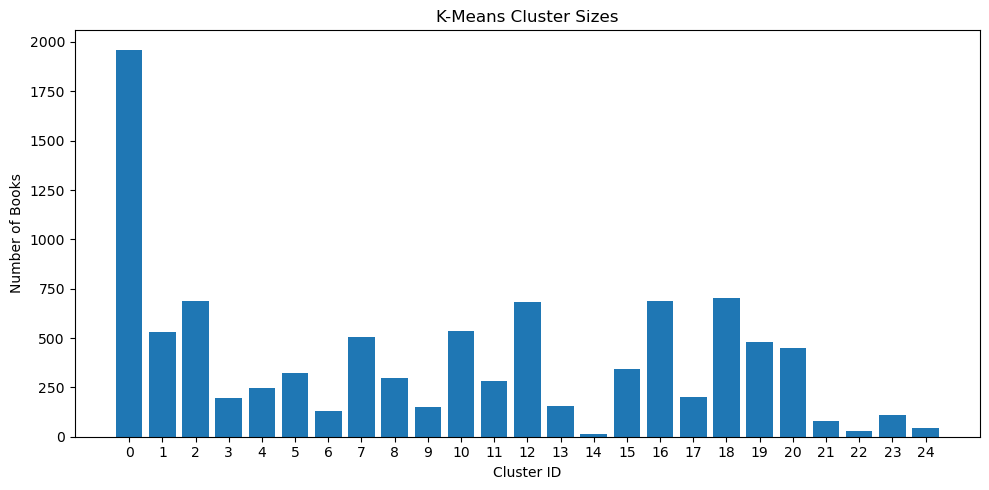

In [93]:
plot_cluster_sizes(df)


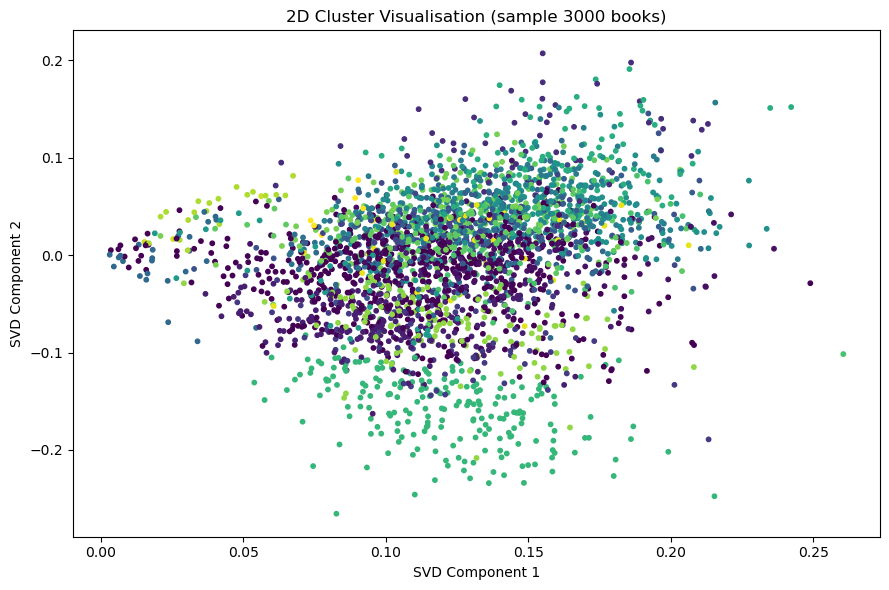

In [95]:
def plot_cluster_scatter(reduced, df, sample_n=3000):
    n = len(df)
    sample_n = min(sample_n, n)
    sample_idx = np.random.choice(n, size=sample_n, replace=False)

    x = reduced[sample_idx, 0]
    y = reduced[sample_idx, 1]
    c = df["Cluster"].iloc[sample_idx].values

    plt.figure(figsize=(9,6))
    plt.scatter(x, y, c=c, s=10)
    plt.xlabel("SVD Component 1")
    plt.ylabel("SVD Component 2")
    plt.title(f"2D Cluster Visualisation (sample {sample_n} books)")
    plt.tight_layout()
    plt.show()

plot_cluster_scatter(reduced, df, sample_n=3000)


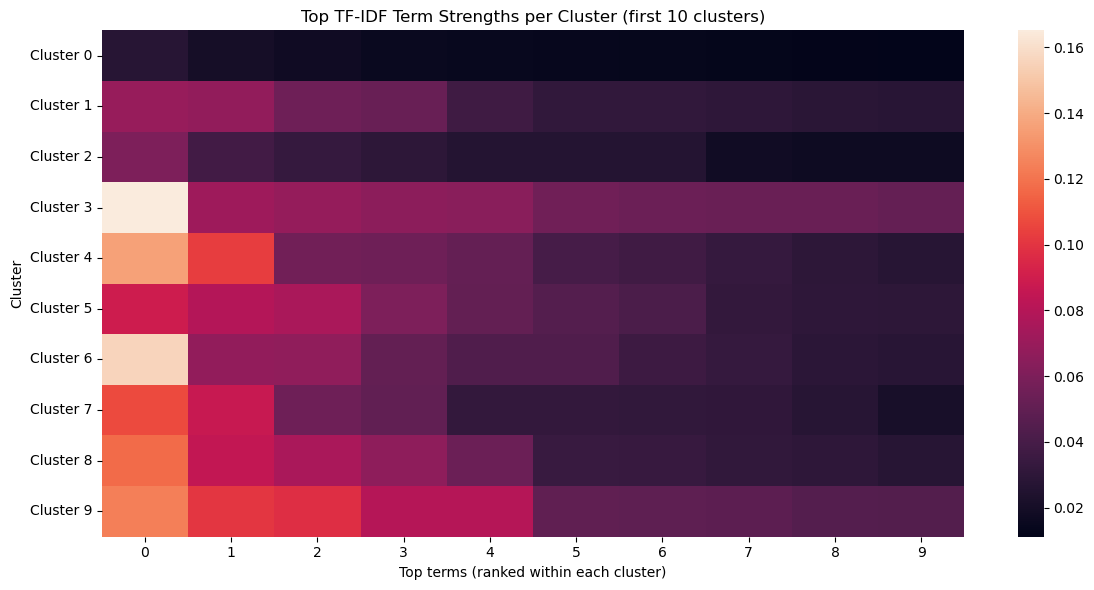

Cluster 0 top terms: life, book, world, story, love, fiction, new, family, time, man
Cluster 1 top terms: romance, contemporary, adult, love, contemporary romance, life, fiction, romance contemporary, new, chick
Cluster 2 top terms: history, nonfiction, philosophy, politics, book, science, world, political, american, new
Cluster 3 top terms: fantasy, fantasy fiction, epic fantasy, high fantasy, epic, fiction, magic, high, fiction fantasy, science fiction
Cluster 4 top terms: god, christian, christianity, religion, faith, bible, jesus, christ, life, book
Cluster 5 top terms: mystery, crime, thriller, detective, mystery thriller, killer, murder, mystery fiction, case, fiction crime
Cluster 6 top terms: war, civil war, civil, history, american, dom, historical, lincoln, dom wars, lucian
Cluster 7 top terms: thriller, mystery, mystery thriller, suspense, thriller mystery, fiction, fiction thriller, crime, fiction mystery, thriller fiction
Cluster 8 top terms: stories, short, short stories,

In [97]:
import seaborn as sns

def plot_cluster_top_terms_heatmap_with_print(df, tfidf_matrix, tfidf_vectorizer, top_terms=10, clusters_to_show=10):
    feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
    cluster_ids = sorted(df["Cluster"].unique())[:clusters_to_show]

    rows = []
    row_labels = []
    top_terms_dict = {}

    for cid in cluster_ids:
        row_pos = np.where(df["Cluster"].to_numpy() == cid)[0]
        mean_vec = np.asarray(tfidf_matrix[row_pos].mean(axis=0)).ravel()

        top_idx = mean_vec.argsort()[::-1][:top_terms]
        rows.append(mean_vec[top_idx])
        row_labels.append(f"Cluster {cid}")

        top_terms_dict[cid] = feature_names[top_idx].tolist()

    heat = np.vstack(rows)

    plt.figure(figsize=(12, 6))
    sns.heatmap(heat)
    plt.title(f"Top TF-IDF Term Strengths per Cluster (first {clusters_to_show} clusters)")
    plt.ylabel("Cluster")
    plt.xlabel("Top terms (ranked within each cluster)")
    plt.yticks(np.arange(len(row_labels)) + 0.5, row_labels, rotation=0)
    plt.tight_layout()
    plt.show()

    for cid in cluster_ids:
        print(f"Cluster {cid} top terms: {', '.join(top_terms_dict[cid])}")

plot_cluster_top_terms_heatmap_with_print(df, tfidf_matrix, tfidf, top_terms=10, clusters_to_show=10)


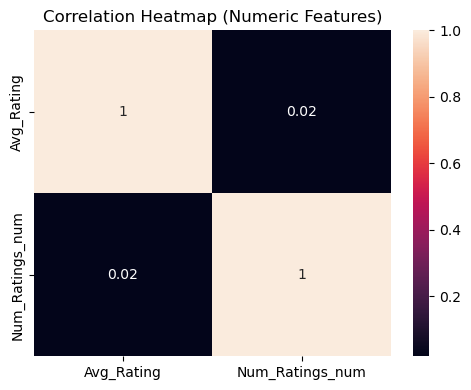

In [99]:
def to_int_ratings(x):
    s = str(x).replace(",", "").strip()
    try:
        return int(float(s))
    except:
        return np.nan

df["Num_Ratings_num"] = df["Num_Ratings"].apply(to_int_ratings)

corr_df = df[["Avg_Rating", "Num_Ratings_num"]].dropna()

plt.figure(figsize=(5,4))
sns.heatmap(corr_df.corr(), annot=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


In [101]:
df = df.reset_index(drop=True)


In [103]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (7856, 9)
Test size: (1964, 9)


In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

def build_text(d):
    return (
        d["Book"].astype(str) + " " +
        d["Author"].astype(str) + " " +
        d["Genres"].astype(str) + " " +
        d["Description"].astype(str)
    )

train_df["text"] = build_text(train_df)
test_df["text"]  = build_text(test_df)

tfidf = TfidfVectorizer(stop_words="english", max_features=15000, ngram_range=(1,2), min_df=2)

X_train = tfidf.fit_transform(train_df["text"])
X_test  = tfidf.transform(test_df["text"])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (7856, 15000)
X_test : (1964, 15000)


In [106]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=11, metric="cosine", algorithm="brute")
knn.fit(X_train)

print("KNN trained on TRAIN set")


KNN trained on TRAIN set


In [107]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

svd = TruncatedSVD(n_components=120, random_state=42)
train_reduced = svd.fit_transform(X_train)
test_reduced  = svd.transform(X_test)

k = 25
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
train_df["Cluster"] = kmeans.fit_predict(train_reduced)
test_df["Cluster"]  = kmeans.predict(test_reduced)

print(" KMeans trained on TRAIN and predicted on TEST")
print("Train clusters:", train_df["Cluster"].nunique())


 KMeans trained on TRAIN and predicted on TEST
Train clusters: 25


In [108]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_from_train(test_title, top_k=10):
    if test_title not in set(test_df["Book"]):
        print("Title not found in TEST set.")
        return

    test_idx = test_df.index[test_df["Book"] == test_title][0]
    sims = cosine_similarity(X_test[test_idx], X_train).flatten()

    top_idx = np.argsort(sims)[::-1][:top_k]
    out = train_df.loc[top_idx, ["Book", "Author", "Genres", "Avg_Rating"]].copy()
    out["Similarity"] = sims[top_idx]
    return out.reset_index(drop=True)

sample_test_title = test_df["Book"].iloc[0]
print("TEST seed:", sample_test_title)
print(recommend_from_train(sample_test_title, top_k=10))


TEST seed: Inga
                           Book              Author  \
0      A Tree Grows in Brooklyn        Betty  Smith   
1          Walking to Bethlehem  Katharine  Barrett   
2                  Cosmic Light    Katerina Kostaki   
3     Magyk (Septimus Heap, #1)          Angie Sage   
4  The Education of Little Tree      Forrest Carter   
5          Famous Family Nights       Anne Bradshaw   
6     ആടുജീവിതം | Aatujeevitham            Benyamin   
7                Family Matters     Rohinton Mistry   
8           Best Of Ruskin Bond         Ruskin Bond   
9              Until I Find You         John Irving   

                                              Genres  Avg_Rating  Similarity  
0  ['Classics', 'Fiction', 'Historical Fiction', ...        4.29    0.130446  
1                                                 []        4.67    0.122830  
2                                                 []        4.92    0.121945  
3  ['Fantasy', 'Young Adult', 'Middle Grade', 'Ma...        3.

In [109]:
import re

def genre_set(g):
    g = str(g).lower()
    parts = re.split(r"[,\|\;/]", g)
    parts = [p.strip() for p in parts if p.strip()]
    return set(parts)

def precision_at_k_for_one(test_idx, k=10):
    seed_genres = genre_set(test_df.loc[test_idx, "Genres"])
    sims = cosine_similarity(X_test[test_idx], X_train).flatten()
    top_idx = np.argsort(sims)[::-1][:k]

    rel = 0
    for i in top_idx:
        rec_genres = genre_set(train_df.loc[i, "Genres"])
        if len(seed_genres.intersection(rec_genres)) > 0:
            rel += 1
    return rel / k

def evaluate_precision_at_k(k=10, n_samples=200, random_state=42):
    rng = np.random.default_rng(random_state)
    sample_idxs = rng.choice(len(test_df), size=min(n_samples, len(test_df)), replace=False)

    scores = [precision_at_k_for_one(i, k=k) for i in sample_idxs]
    return float(np.mean(scores)), float(np.std(scores))

mean_p, std_p = evaluate_precision_at_k(k=10, n_samples=200)
print(f"Precision@10 (genre overlap proxy): {mean_p:.3f} ± {std_p:.3f}")


Precision@10 (genre overlap proxy): 0.713 ± 0.283


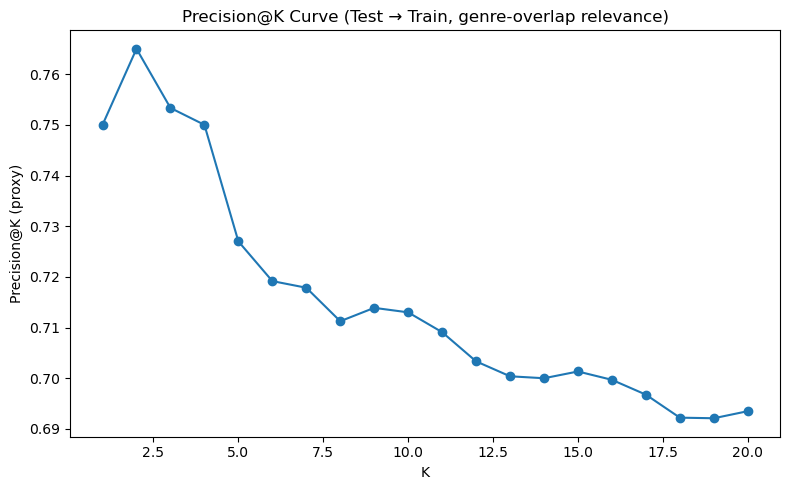

In [110]:
Ks = list(range(1, 21))
means = []
for k in Ks:
    m, _ = evaluate_precision_at_k(k=k, n_samples=200)
    means.append(m)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(Ks, means, marker="o")
plt.xlabel("K")
plt.ylabel("Precision@K (proxy)")
plt.title("Precision@K Curve (Test → Train, genre-overlap relevance)")
plt.tight_layout()
plt.show()


In [115]:
import re

def genre_set(g):
    g = str(g).lower()
    parts = re.split(r"[,\|\;/\[\]']", g)
    parts = [p.strip() for p in parts if p.strip()]
    return set(parts)

train_genres = [genre_set(g) for g in train_df["Genres"].tolist()]
test_genres  = [genre_set(g) for g in test_df["Genres"].tolist()]



In [117]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def recommend_content(test_i, top_k=10):
    sims = cosine_similarity(X_test[test_i], X_train).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    return top_idx, sims[top_idx]


In [118]:
def recommend_knn(test_i, top_k=10):
    distances, indices = knn.kneighbors(X_test[test_i], n_neighbors=top_k)
    distances = distances.flatten()
    indices = indices.flatten()
    sims = 1 - distances
    return indices, sims


In [119]:
def recommend_kmeans_cluster(test_i, top_k=10):
    cid = test_df.loc[test_i, "Cluster"]
    candidates = np.where(train_df["Cluster"].to_numpy() == cid)[0]
    if len(candidates) == 0:
        return np.array([], dtype=int), np.array([])

    sims_all = cosine_similarity(X_test[test_i], X_train[candidates]).flatten()
    order = np.argsort(sims_all)[::-1][:top_k]
    top_idx = candidates[order]
    return top_idx, sims_all[order]


In [120]:
def precision_at_k(recommended_idx, seed_genres, k):
    if len(recommended_idx) == 0:
        return 0.0
    recommended_idx = recommended_idx[:k]
    rel = 0
    for j in recommended_idx:
        if seed_genres & train_genres[j]:
            rel += 1
    return rel / k


In [121]:
import pandas as pd

def evaluate_models_precision(k=10, n_samples=200, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples = min(n_samples, len(test_df))
    sample = rng.choice(len(test_df), size=n_samples, replace=False)

    results = {"Content": [], "KNN": [], "KMeansCluster": []}

    for i in sample:
        seed = test_genres[i]

        idx_c, _ = recommend_content(i, top_k=k)
        idx_k, _ = recommend_knn(i, top_k=k)
        idx_m, _ = recommend_kmeans_cluster(i, top_k=k)

        results["Content"].append(precision_at_k(idx_c, seed, k))
        results["KNN"].append(precision_at_k(idx_k, seed, k))
        results["KMeansCluster"].append(precision_at_k(idx_m, seed, k))

    summary = {m: (float(np.mean(v)), float(np.std(v))) for m, v in results.items()}
    return summary

summary = evaluate_models_precision(k=10, n_samples=200)
summary


{'Content': (0.7895000000000002, 0.29671493053097275),
 'KNN': (0.7895000000000002, 0.29671493053097275),
 'KMeansCluster': (0.831, 0.31959192730730857)}

In [122]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

def proxy_confusion_for_model(model_name="Content", k=10, sim_threshold=0.30, n_samples=200, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples = min(n_samples, len(test_df))
    sample = rng.choice(len(test_df), size=n_samples, replace=False)

    y_true = []
    y_pred = []

    for i in sample:
        seed = test_genres[i]

        if model_name == "Content":
            idxs, sims = recommend_content(i, top_k=k)
        elif model_name == "KNN":
            idxs, sims = recommend_knn(i, top_k=k)
        else:
            idxs, sims = recommend_kmeans_cluster(i, top_k=k)

        # for each recommended item: true relevant? predicted relevant?
        for j, s in zip(idxs, sims):
            true_rel = 1 if (seed & train_genres[j]) else 0
            pred_rel = 1 if (s >= sim_threshold) else 0
            y_true.append(true_rel)
            y_pred.append(pred_rel)

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    return cm, acc, prec, rec

cm_c, acc_c, p_c, r_c = proxy_confusion_for_model("Content")
cm_k, acc_k, p_k, r_k = proxy_confusion_for_model("KNN")
cm_m, acc_m, p_m, r_m = proxy_confusion_for_model("KMeansCluster")

(acc_c, p_c, r_c), (acc_k, p_k, r_k), (acc_m, p_m, r_m)


((0.304, 0.8945147679324894, 0.13426219126029132),
 (0.304, 0.8945147679324894, 0.13426219126029132),
 (0.2475, 0.8944723618090452, 0.10709987966305656))

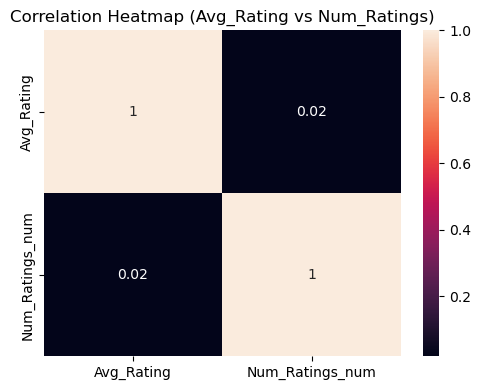

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

def to_int_ratings(x):
    s = str(x).replace(",", "").strip()
    try:
        return int(float(s))
    except:
        return np.nan

tmp = df.copy()
tmp["Num_Ratings_num"] = tmp["Num_Ratings"].apply(to_int_ratings)

corr_df = tmp[["Avg_Rating", "Num_Ratings_num"]].dropna()

plt.figure(figsize=(5,4))
sns.heatmap(corr_df.corr(), annot=True)
plt.title("Correlation Heatmap (Avg_Rating vs Num_Ratings)")
plt.tight_layout()
plt.show()


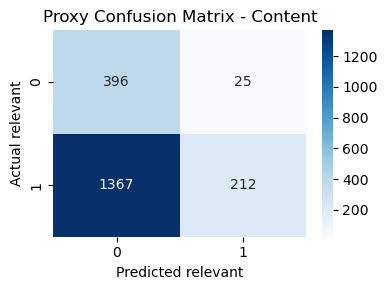

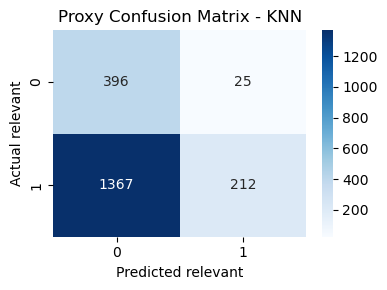

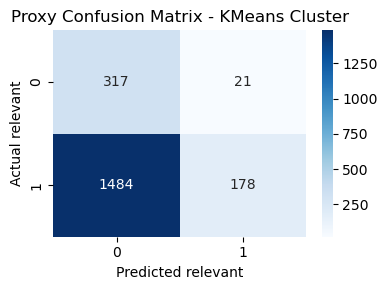

In [124]:
from sklearn.metrics import confusion_matrix as cmc

def plot_cm(cm, title):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted relevant")
    plt.ylabel("Actual relevant")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cm(cm_c, "Proxy Confusion Matrix - Content")
plot_cm(cm_k, "Proxy Confusion Matrix - KNN")
plot_cm(cm_m, "Proxy Confusion Matrix - KMeans Cluster")


           Model  Precision@10_mean  Precision@10_std
2  KMeansCluster             0.8310          0.319592
0        Content             0.7895          0.296715
1            KNN             0.7895          0.296715


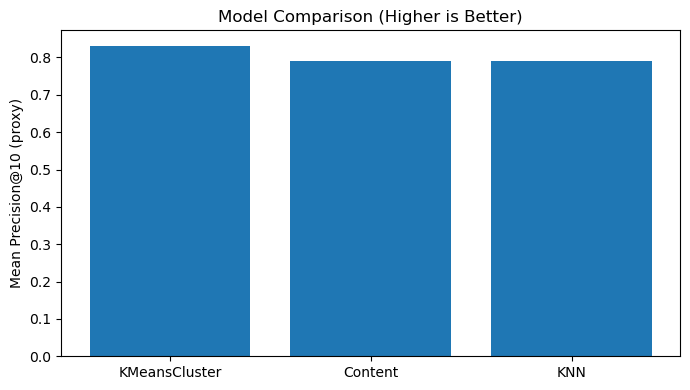

In [125]:

rows = []
for model, (mean_p, std_p) in summary.items():
    rows.append({"Model": model, "Precision@10_mean": mean_p, "Precision@10_std": std_p})

comp_df = pd.DataFrame(rows).sort_values("Precision@10_mean", ascending=False)
print(comp_df)

plt.figure(figsize=(7,4))
plt.bar(comp_df["Model"], comp_df["Precision@10_mean"])
plt.ylabel("Mean Precision@10 (proxy)")
plt.title("Model Comparison (Higher is Better)")
plt.tight_layout()
plt.show()


In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
  

In [139]:
df = pd.read_csv("goodreads_cleaned.csv")
df = df.reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (9820, 6)


,Book,Author,Description,Genres,Avg_Rating,Num_Ratings
0,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"['Classics', 'Fiction', 'Historical Fiction', ...",4.27,"5,691,311"
1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,Harry Potter thinks he is an ordinary boy - un...,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4.47,"9,278,135"
2,Pride and Prejudice,Jane Austen,"Since its immediate success in 1813, Pride and...","['Classics', 'Fiction', 'Romance', 'Historical...",4.28,"3,944,155"
3,The Diary of a Young Girl,Anne Frank,Discovered in the attic in which she spent the...,"['Classics', 'Nonfiction', 'History', 'Biograp...",4.18,"3,488,438"
4,Animal Farm,George Orwell,Librarian's note: There is an Alternate Cover ...,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",3.98,"3,575,172"


In [141]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)


Train size: (7856, 6)
Test size: (1964, 6)


In [143]:
def build_text(d):
    return (
        d["Book"].astype(str) + " " +
        d["Author"].astype(str) + " " +
        d["Genres"].astype(str) + " " +
        d["Description"].astype(str)
    )

train_df["text"] = build_text(train_df)
test_df["text"] = build_text(test_df)

tfidf = TfidfVectorizer(stop_words="english", max_features=15000)
X_train = tfidf.fit_transform(train_df["text"])
X_test = tfidf.transform(test_df["text"])

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (7856, 15000)
X_test: (1964, 15000)


In [145]:
knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(X_train)

print("KNN trained")


KNN trained


In [147]:
svd = TruncatedSVD(n_components=120, random_state=42)
train_red = svd.fit_transform(X_train)
test_red = svd.transform(X_test)

kmeans = KMeans(n_clusters=25, random_state=42, n_init="auto")
train_df["Cluster"] = kmeans.fit_predict(train_red)
test_df["Cluster"] = kmeans.predict(test_red)

print("KMeans trained")


KMeans trained


In [149]:
import re

def genre_set(g):
    g = str(g).lower()
    parts = re.split(r"[,\|\;/\[\]']", g)
    return set(p.strip() for p in parts if p.strip())

train_genres = [genre_set(g) for g in train_df["Genres"]]
test_genres = [genre_set(g) for g in test_df["Genres"]]


In [151]:
def recommend_content(i, top_k=10):
    sims = cosine_similarity(X_test[i], X_train).flatten()
    idx = np.argsort(sims)[::-1][:top_k]
    return idx, sims[idx]

def recommend_knn(i, top_k=10):
    dists, idx = knn.kneighbors(X_test[i], n_neighbors=top_k)
    sims = 1 - dists.flatten()
    return idx.flatten(), sims

def recommend_kmeans_cluster(i, top_k=10):
    cid = test_df.loc[i, "Cluster"]
    candidates = np.where(train_df["Cluster"] == cid)[0]
    sims = cosine_similarity(X_test[i], X_train[candidates]).flatten()
    order = np.argsort(sims)[::-1][:top_k]
    return candidates[order], sims[order]


In [153]:
def precision_curve_all(Ks=range(1, 21), n_samples=100):
    rng = np.random.default_rng(42)
    sample = rng.choice(len(test_df), size=min(n_samples, len(test_df)), replace=False)

    curves = {"Content": [], "KNN": [], "KMeans": []}

    for k in Ks:
        pc, pk, pm = [], [], []

        for i in sample:
            seed = test_genres[i]

            idx_c, _ = recommend_content(i, top_k=k)
            idx_k, _ = recommend_knn(i, top_k=k)
            idx_m, _ = recommend_kmeans_cluster(i, top_k=k)

            pc.append(precision_at_k(idx_c, seed, k))
            pk.append(precision_at_k(idx_k, seed, k))
            pm.append(precision_at_k(idx_m, seed, k))

        curves["Content"].append(float(np.mean(pc)))
        curves["KNN"].append(float(np.mean(pk)))
        curves["KMeans"].append(float(np.mean(pm)))

    return list(Ks), curves



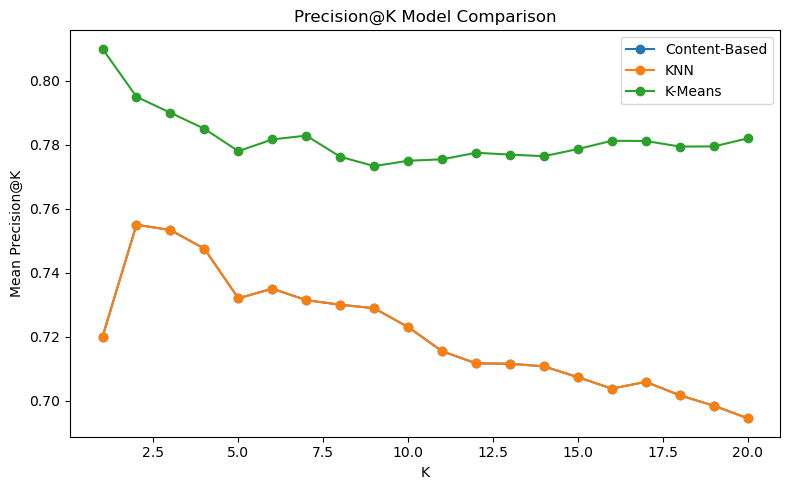

In [155]:
Ks, curves = precision_curve_all(Ks=range(1, 21), n_samples=100)

plt.figure(figsize=(8,5))
plt.plot(Ks, curves["Content"], marker="o", label="Content-Based")
plt.plot(Ks, curves["KNN"], marker="o", label="KNN")
plt.plot(Ks, curves["KMeans"], marker="o", label="K-Means")
plt.xlabel("K")
plt.ylabel("Mean Precision@K")
plt.title("Precision@K Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [156]:
import pandas as pd

print("Ks exists:", "Ks" in globals())
print("curves exists:", "curves" in globals())

k10_index = Ks.index(10)


comp_df = pd.DataFrame({
    "Model": ["Content-Based", "KNN", "K-Means"],
    "Precision@10_mean": [
        curves["Content"][k10_index],
        curves["KNN"][k10_index],
        curves["KMeans"][k10_index]
    ]
})

print("Model comparison table created")
comp_df


Ks exists: True
curves exists: True
Model comparison table created


,Model,Precision@10_mean
0,Content-Based,0.723
1,KNN,0.723
2,K-Means,0.775


In [157]:
best_row = comp_df.loc[comp_df["Precision@10_mean"].idxmax()]
best_model = best_row["Model"]
best_score = best_row["Precision@10_mean"]

print(f"Best performing model (by Precision@10): {best_model} with {best_score:.3f}")


Best performing model (by Precision@10): K-Means with 0.775


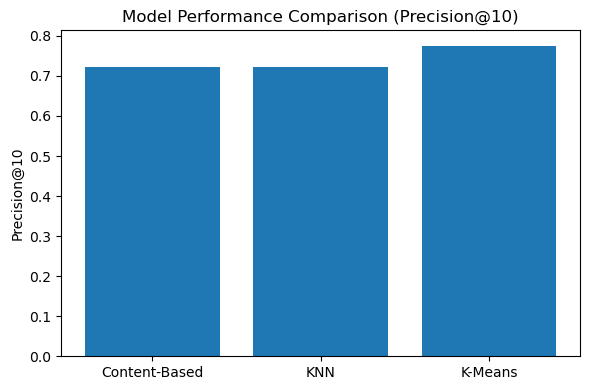

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(comp_df["Model"], comp_df["Precision@10_mean"])
plt.ylabel("Precision@10")
plt.title("Model Performance Comparison (Precision@10)")
plt.tight_layout()
plt.show()


In [166]:
def get_kmeans_recs(test_title, top_k=10):
    # Check if title exists in test set
    if test_title not in set(test_df["Book"].astype(str)):
        return pd.DataFrame()

 
    test_idx = test_df.index[test_df["Book"].astype(str) == str(test_title)][0]
    q_cluster = test_df.loc[test_idx, "Cluster"]

   
    same_cluster = train_df[train_df["Cluster"] == q_cluster].copy()
    if len(same_cluster) == 0:
        return pd.DataFrame()

 
    out = same_cluster.sort_values("Avg_Rating", ascending=False).head(top_k)
    out = out[["Book", "Author", "Genres", "Avg_Rating"]].copy()
    out["Method"] = "K-Means (Same Cluster)"

    out["Score"] = (
        (out["Avg_Rating"] - out["Avg_Rating"].min()) /
        (out["Avg_Rating"].max() - out["Avg_Rating"].min() + 1e-9)
    )

    return out.reset_index(drop=True)


In [168]:
sample_title = test_df["Book"].iloc[0]
km_recs = get_kmeans_recs(sample_title, top_k=10)
km_recs


,Book,Author,Genres,Avg_Rating,Method,Score
0,Maternal Menace,Terri Ann Armstrong,[],5.0,K-Means (Same Cluster),0.0
1,Touch: Making Contact With Climate Change,Ben Cromwell,[],5.0,K-Means (Same Cluster),0.0
2,WOLF WHISPERER SERIES Vol 1 & 2,Angeline Gallant,[],5.0,K-Means (Same Cluster),0.0
3,Wasteland,Antoine Laurier Harding,[],5.0,K-Means (Same Cluster),0.0
4,The Brugan,Stephen Moore,[],5.0,K-Means (Same Cluster),0.0
5,Reason,Riley Pirtle,[],5.0,K-Means (Same Cluster),0.0
6,When Everything Good Comes,Oluwakemi Omowaire,[],5.0,K-Means (Same Cluster),0.0
7,A New Forest Witch,Siobhan Searle,[],5.0,K-Means (Same Cluster),0.0
8,Tramps 47: From Prison to Parkbench to Pulpit,Lynette Sloane,[],5.0,K-Means (Same Cluster),0.0
9,Survival of the Fittest and How the Lost Boy S...,Mator Adol Mawien,[],5.0,K-Means (Same Cluster),0.0
